In [1]:
# set up autoreload for the locator module
%load_ext autoreload
%autoreload 2

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # Suppress TF logging
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # Use specific GPU
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Suppress oneDNN messages

import os

import locator
from locator import Locator, plot_error_summary, plot_predictions

In [2]:
vcf_path = "/sietch_colab/data_share/turtles_Actinemys/58-Actinemys/QC/58-Actinemys.pruned.vcf.gz"
coords_path = "/sietch_colab/data_share/turtles_Actinemys/actinemys_locator_metadata.tsv"
output_dir = "/sietch_colab/data_share/turtles_Actinemys/locator_output"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Configuration for Locator
config = {
    "out": os.path.join(output_dir, "actinemys_basic"),
    "sample_data": coords_path,
    "vcf": vcf_path,
    "batch_size": 32,
    "width": 256,  # Number of units in hidden layers
    "nlayers": 8,  # Number of hidden layers
    "dropout_prop": 0.25,
    "max_epochs": 500,  # FIXED: was "epochs"
    "train_split": 0.8,  # FIXED: was "test_split" (0.2), now correct proportion for training
    "patience": 100,  # Early stopping patience
    "keras_verbose": 0,  # Suppress keras output since verbose=False in k-fold
    "weight_samples": {
        "enabled": False,  # Enable sample weighting
        "method": "KD",  # Use holdout method for training
        "xbins": 30,
        "ybins": 30,
    },
    # "disable_gpu": False,  # Force CPU-only execution
    # "gpu_number": [1, 2],
    "verbose_splits": True,
    "holdout_no_intermediate_saves": True,
}

# Create Locator instance
locator = Locator(config)

# Load genotype data
print("\nLoading genotype data from VCF...")
genotypes, samples = locator.load_genotypes(vcf=vcf_path)
print(f"Loaded genotypes shape: {genotypes.shape}")
print(f"Number of samples: {len(samples)}")
print(f"Number of SNPs: {genotypes.shape[0]}")

Using GPU 0: /physical_device:GPU:0
Mixed precision training enabled (compute capability (8, 0))

Loading genotype data from VCF...
reading VCF


[read_vcf] 65536 rows in 4.50s; chunk in 4.50s (14565 rows/s); JALMGD010000009.1 :19722825
[read_vcf] 100126 rows in 6.89s; chunk in 2.39s (14447 rows/s)
[read_vcf] all done (14522 rows/s)


Loaded genotypes shape: (100126, 231, 2)
Number of samples: 231
Number of SNPs: 100126



Holdout split summary:
  Training samples: 182 (78.8%)
  Validation samples: 46 (19.9%)
  Holdout samples: 3 (1.3%)
  Total samples: 231
  Total SNPs: 100114


I0000 00:00:1751307518.344590 2264097 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78670 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
I0000 00:00:1751307525.236990 2264649 cuda_dnn.cc:527] Loaded cuDNN version 90300
I0000 00:00:1751307532.353378 2264649 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Saved final model weights to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Predicting locations for holdout samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


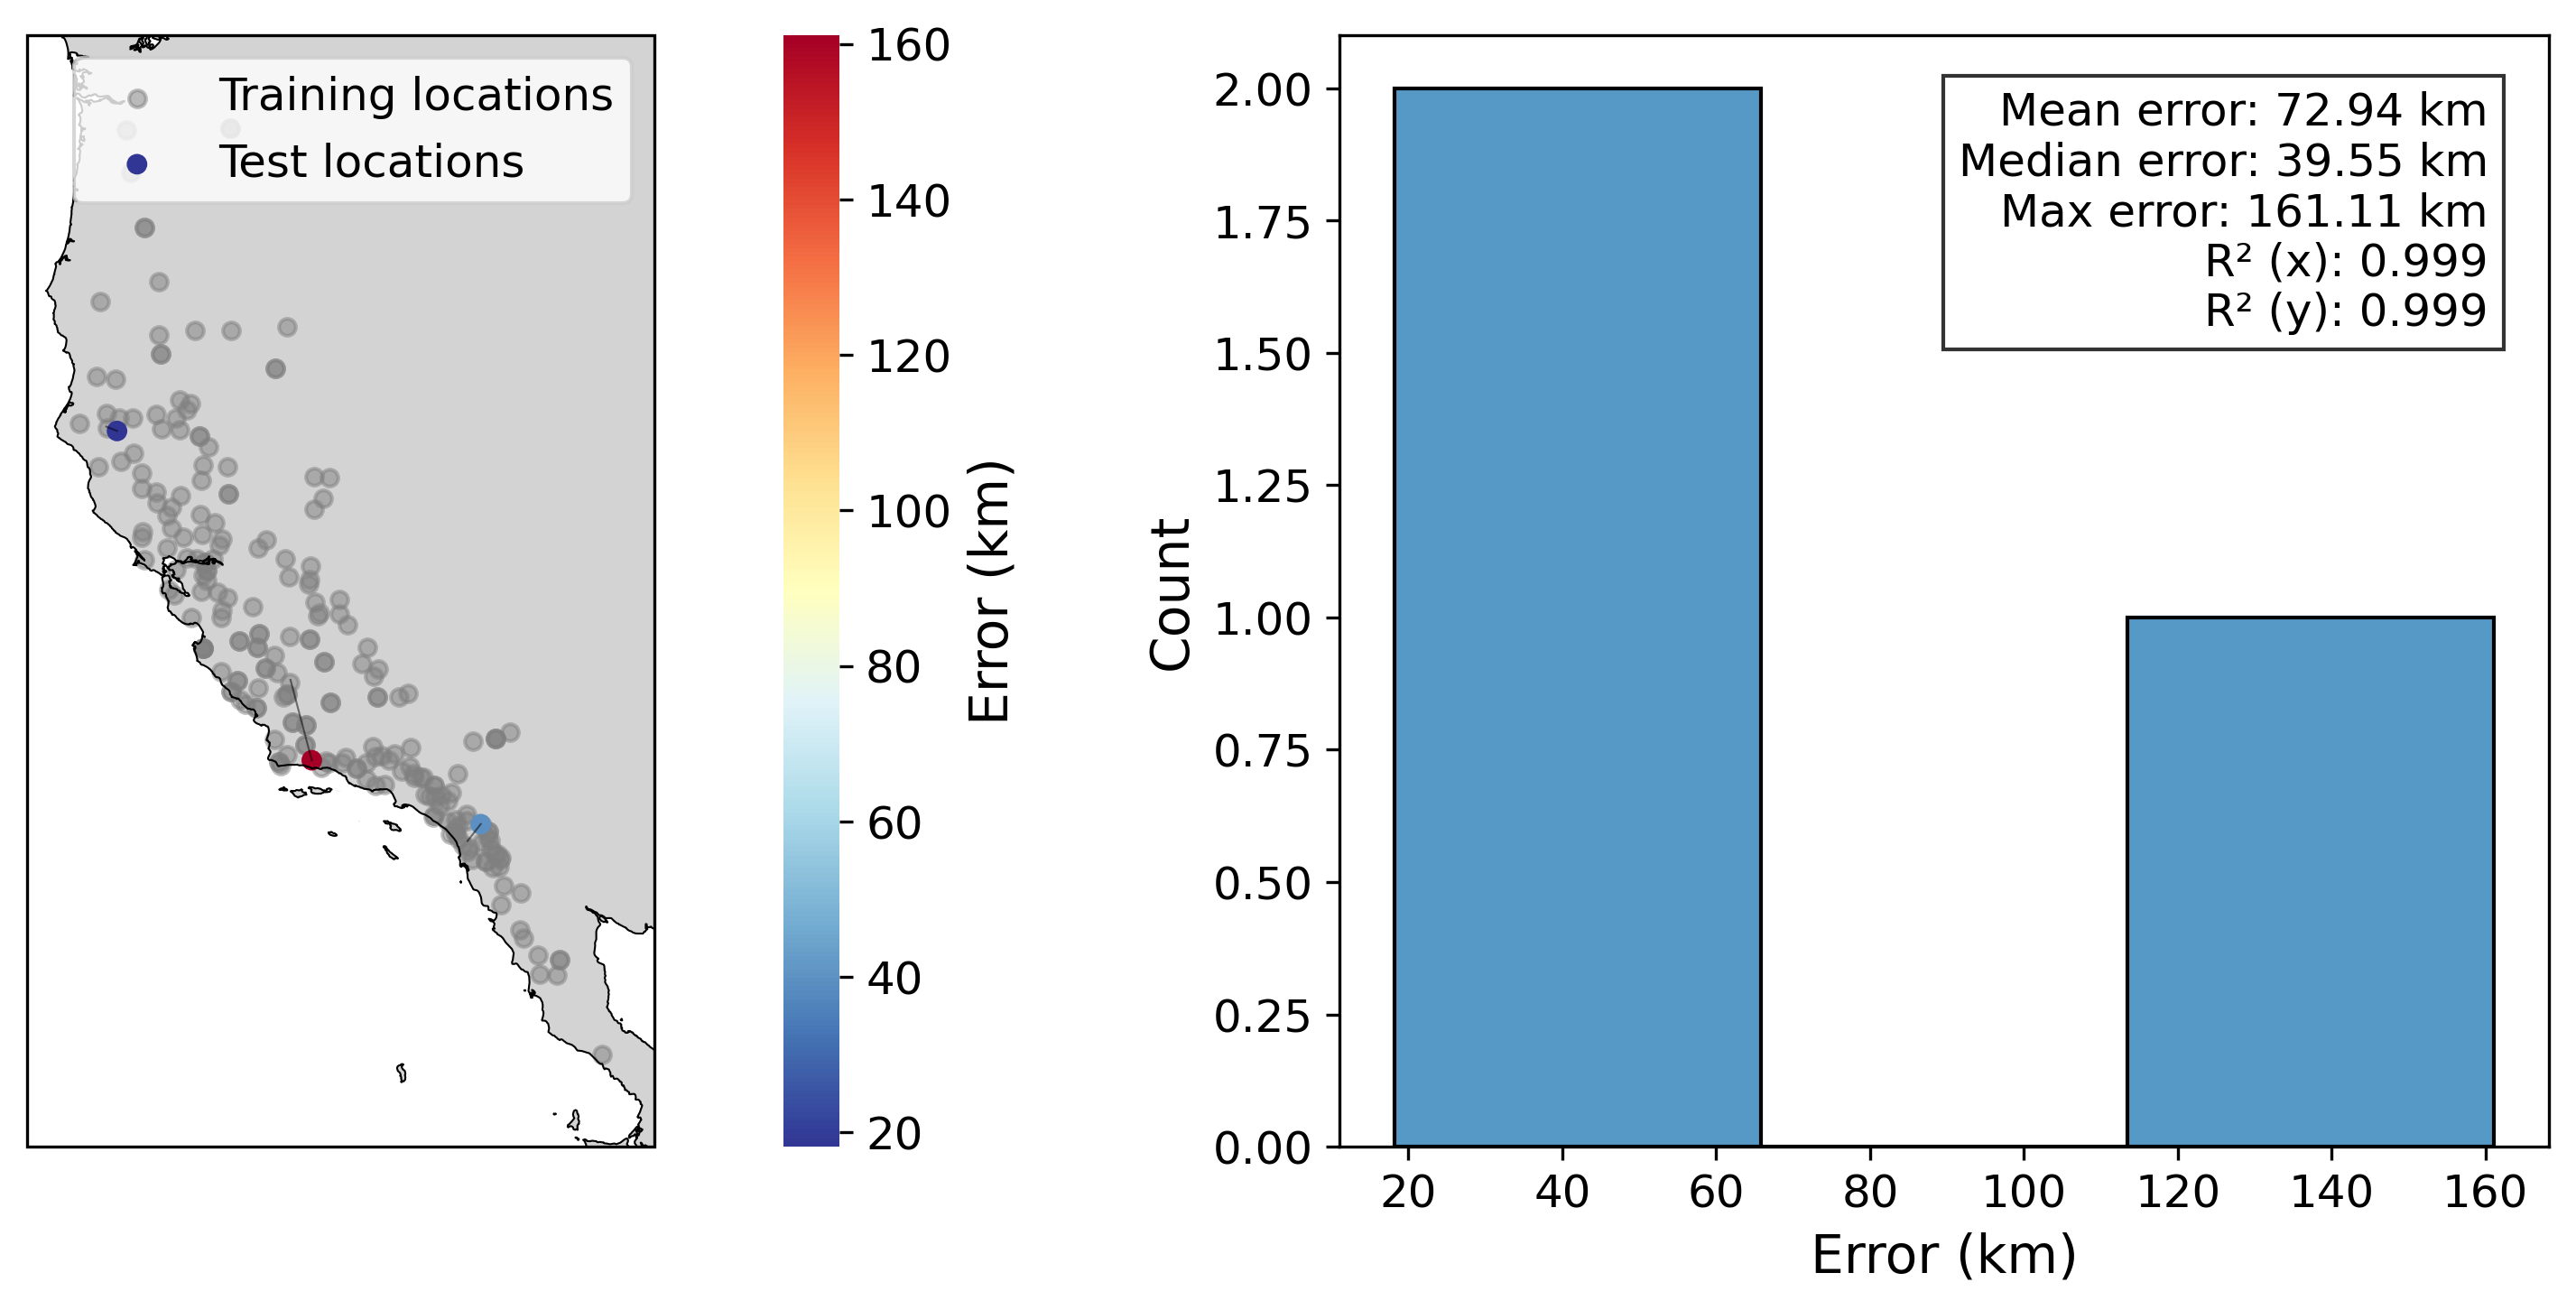

         19636131 function calls (19155314 primitive calls) in 55.414 seconds

   Ordered by: internal time
   List reduced from 7326 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1659   20.883    0.013   20.883    0.013 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_Execute}
      257    6.285    0.024    6.292    0.024 {built-in method posix.fork}
    10562    4.317    0.000    4.328    0.000 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_FastPathExecute}
      192    2.457    0.013    2.457    0.013 {built-in method time.sleep}
     5258    2.258    0.000    2.258    0.000 {method '_numpy_internal' of 'tensorflow.python.framework.ops.EagerTensor' objects}
     7966    0.596    0.000    0.596    0.000 {method 'copy' of 'numpy.ndarray' objects}
    11738    0.595    0.000    0.899    0.000 coords.py:109(xy)
        2    0.468    0.234    4.056    2.028 shapereader.py:196(__init__)
   446330    0.440    0.000  

In [3]:
%%prun -l 20
locator.train_holdout(
    genotypes=genotypes,
    samples=samples,
    k=3,
)
preds = locator.predict_holdout(return_df=True)

In [ ]:
locator

In [14]:
%%prun -l 20
ho_preds = locator.run_k_fold_holdouts(
    genotypes, samples, k=10, verbose=False, return_df=True
)

I0000 00:00:1751340956.295781 2118163 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79091 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


Limiting max batch size to 32 based on dataset size 166
Adjusted batch size for small dataset: 32
Optimal batch size determined: 32
Using optimized batch size: 32


I0000 00:00:1751340963.504186 2232704 cuda_dnn.cc:527] Loaded cuDNN version 90300
I0000 00:00:1751340971.261149 2232704 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Limiting max batch size to 32 based on dataset size 166
Adjusted batch size for small dataset: 32
Optimal batch size determined: 32
Using optimized batch size: 32
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Limiting max batch size to 32 based on dataset size 166
Adjusted batch size for small dataset: 32
Optimal batch size determined: 32
Using optimized batch size: 32
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Limiting max batch size to 32 based on dataset size 166
Adjusted batch size for small dataset: 32
Optimal batch size determined: 32
Using optimized batch size: 32
Model metadata saved to /sietch_colab/data_share/turtles_Actinemys/locator_output/actinemys_basic.weights.h5
Limiting max batch size to 32 based on dataset size 166
Adjusted batch size

         83199049 function calls (79221131 primitive calls) in 1878.019 seconds

   Ordered by: internal time
   List reduced from 4122 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    29280  311.464    0.011  418.851    0.014 {built-in method numpy.array}
   143464  306.031    0.002  306.160    0.002 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_FastPathExecute}
    19298  252.058    0.013  252.058    0.013 {method 'copy' of 'numpy.ndarray' objects}
    19159  160.022    0.008  160.022    0.008 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_Execute}
       10  138.107   13.811 1819.426  181.943 trainer.py:291(fit)
 4562/160  136.289    0.030 1842.575   11.516 traceback_utils.py:110(error_handler)
     2727  136.141    0.050  137.015    0.050 epoch_iterator.py:89(reset)
    24473  134.693    0.006  420.189    0.017 epoch_iterator.py:96(_enumerate_iterator)
    19700   79.074    0.004   79.337    0.004 dataset.py:3

In [ ]:
ho_preds

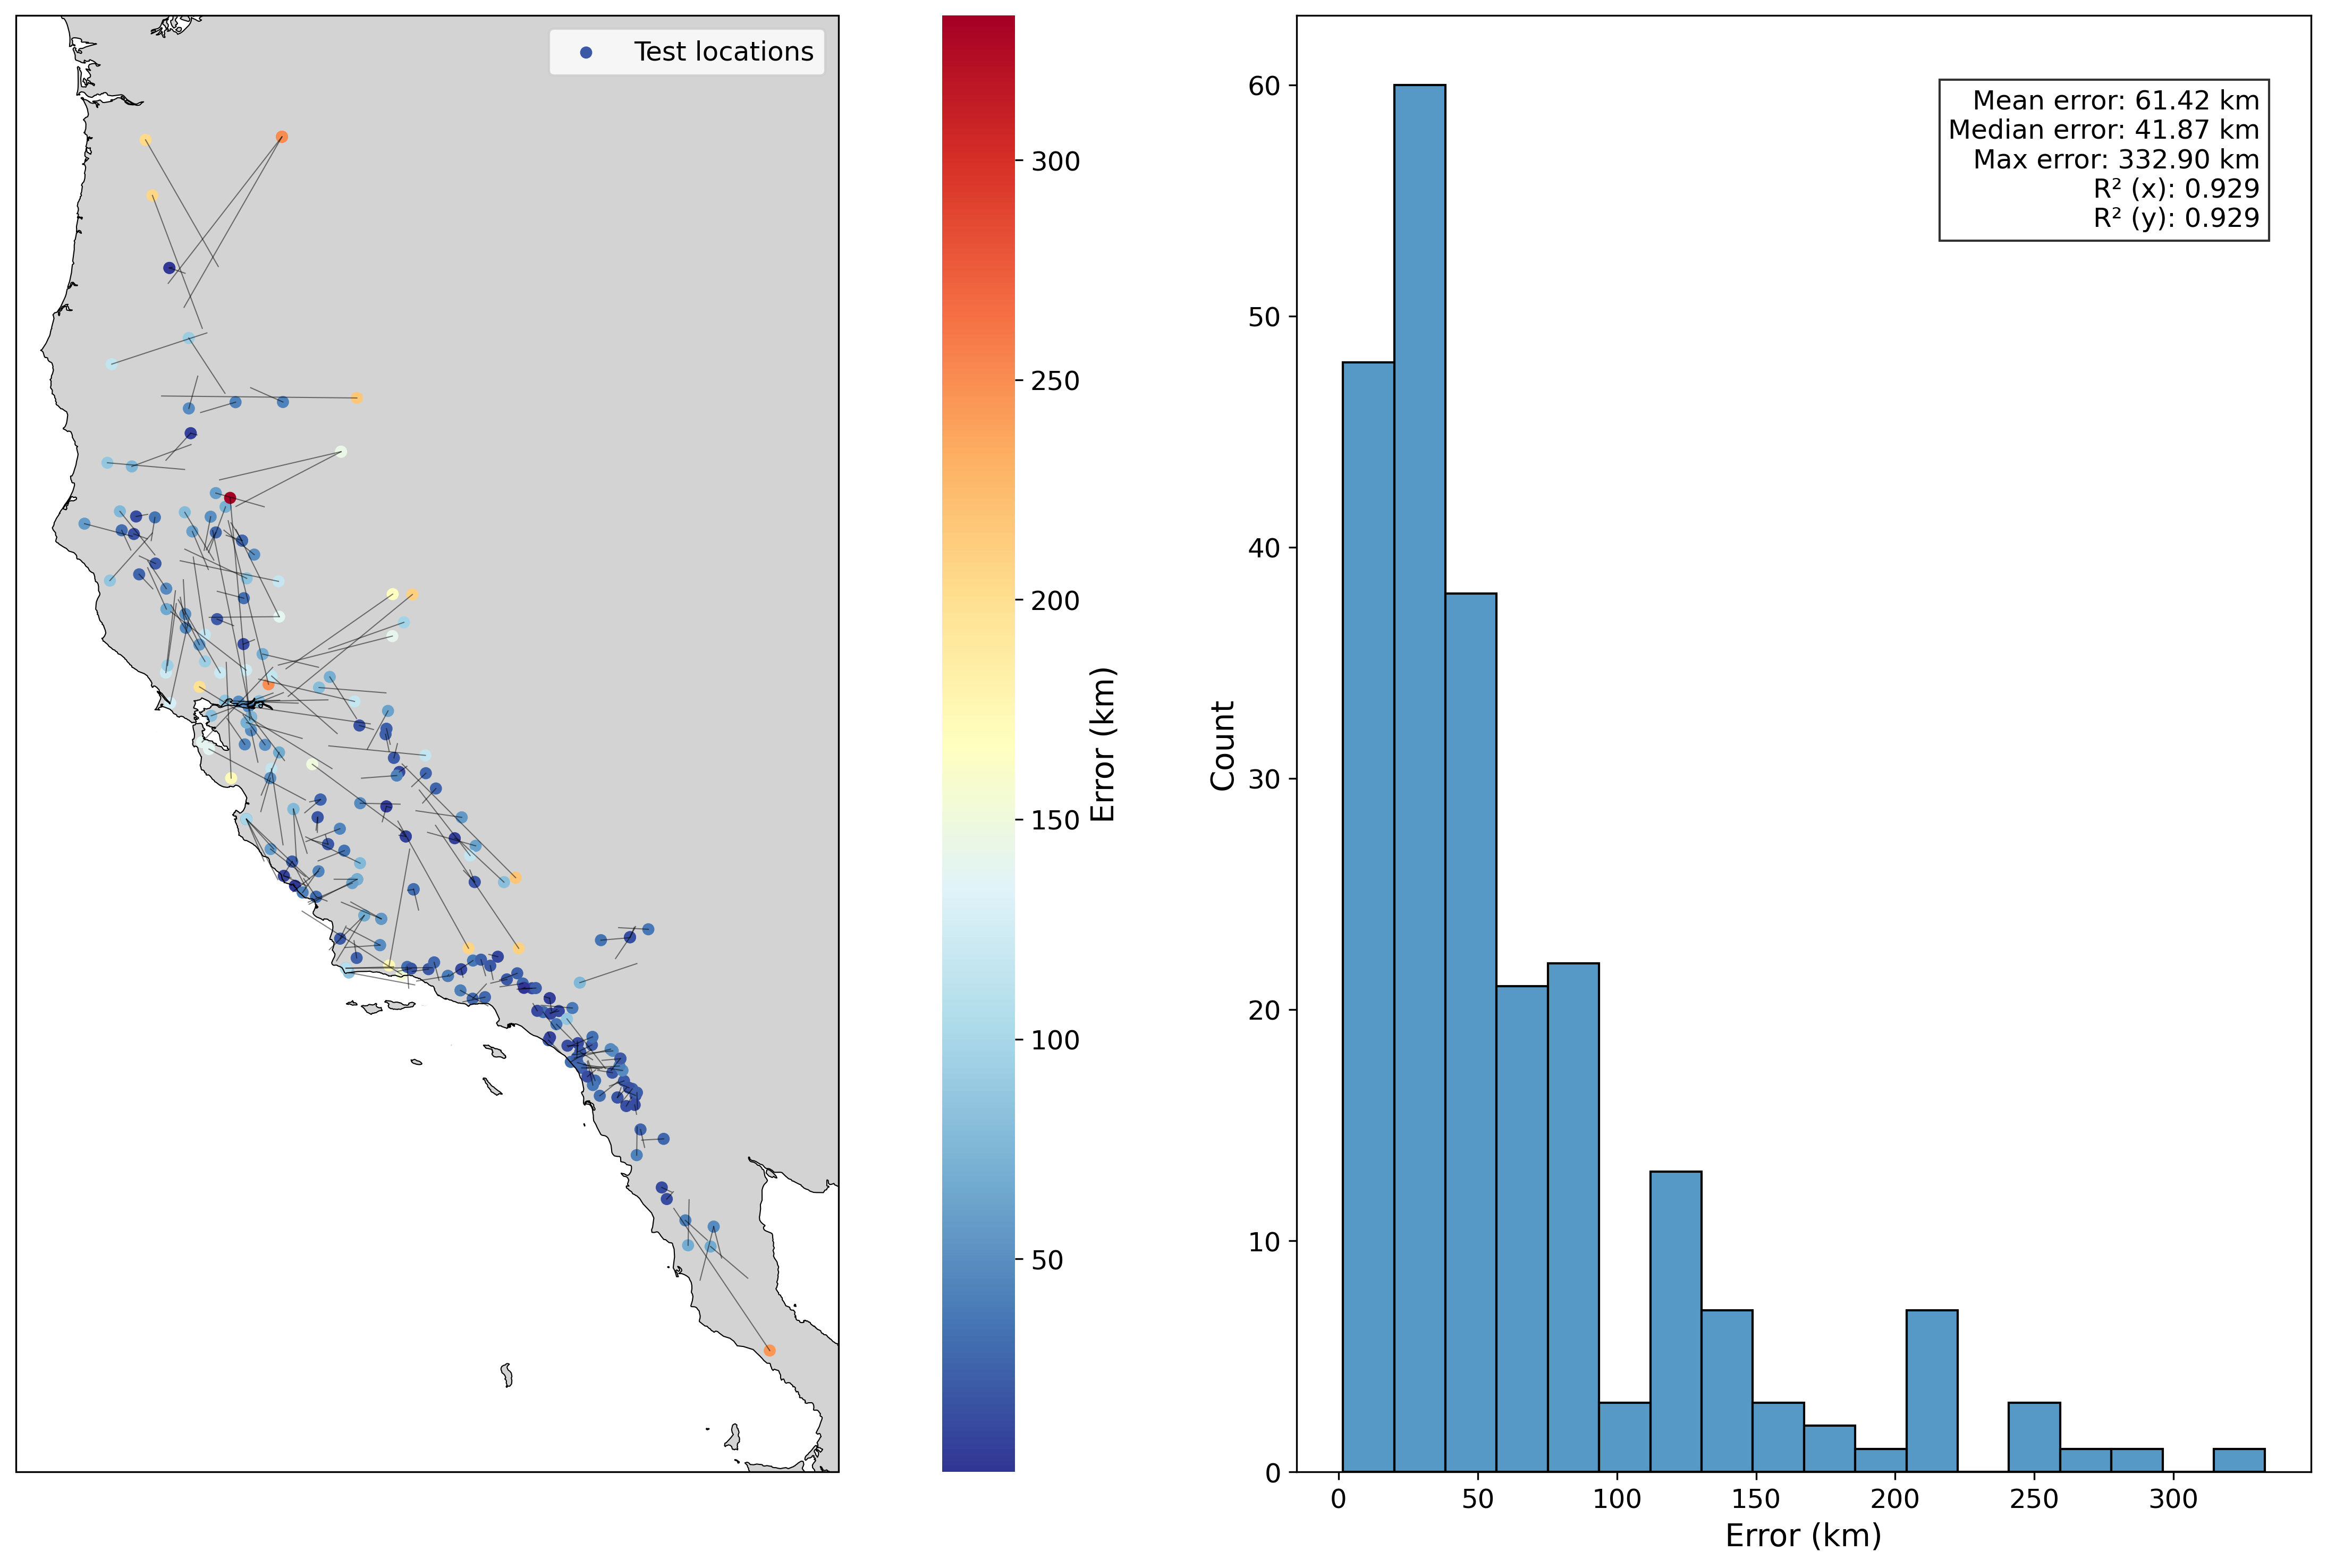

In [15]:
plot_error_summary(
    predictions=ho_preds,
    sample_data=coords_path,
    plot_map=True,
    include_training_locs=True,
)

In [ ]:
loo = locator.run_leave_one_out(genotypes, samples, return_df=True)

In [ ]:
plot_error_summary(
    predictions=loo,
    sample_data=coords_path,
    plot_map=True,
    include_training_locs=True,
)

In [3]:
from locator.parallel import parallel_k_fold_holdouts

par_results = parallel_k_fold_holdouts(
    locator=locator,
    genotypes=genotypes,
    samples=samples,
    k=3,
    gpu_ids=[2],
    gpu_fraction=0.1,
    return_df=True,
    save_full_pred_matrix=False,
    verbose=True,
)

K-fold CV: 231 samples with coordinates, 0 without
Running true 3-fold cross-validation across GPUs [2] using Ray...
Submitted fold 0 to GPU 2
Submitted fold 1 to GPU 2
Submitted fold 2 to GPU 2

Processing folds across GPUs...


Folds completed: 100%|██████████| 3/3 [00:46<00:00, 15.36s/it, Last: Fold 2, GPU 2]


Completed 3-fold CV in 46.1s (15.4s per fold)


In [2]:
# fig = plot_error_summary(
#     predictions=par_results,
#     sample_data=coords_path,
#     plot_map=True,
#     include_training_locs=True,
#     interactive=True,
#     #out_prefix="foo"
# )
from locator.plotting import plot_error_summary, plot_interactive_error_map

plot_interactive_error_map(
    predictions=par_results,
    sample_data=coords_path,
    out_prefix="actinemys_interactive",
    width=600,
    height=600,
    include_training_locs=True,
    show_histogram=False,
)

2025-07-14 19:54:39.925365: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


NameError: name 'par_results' is not defined

In [9]:
fig

In [ ]:
from locator.parallel import parallel_leave_one_out

par_loo = parallel_leave_one_out(
    locator=locator,
    genotypes=genotypes,
    samples=samples,
    gpu_ids=[1, 2],
    gpu_fraction=0.05,  # 20 jobs per GPU
    return_df=True,
    save_full_pred_matrix=False,
)

Running leave-one-out cross-validation for 231 samples across GPUs [1, 2]


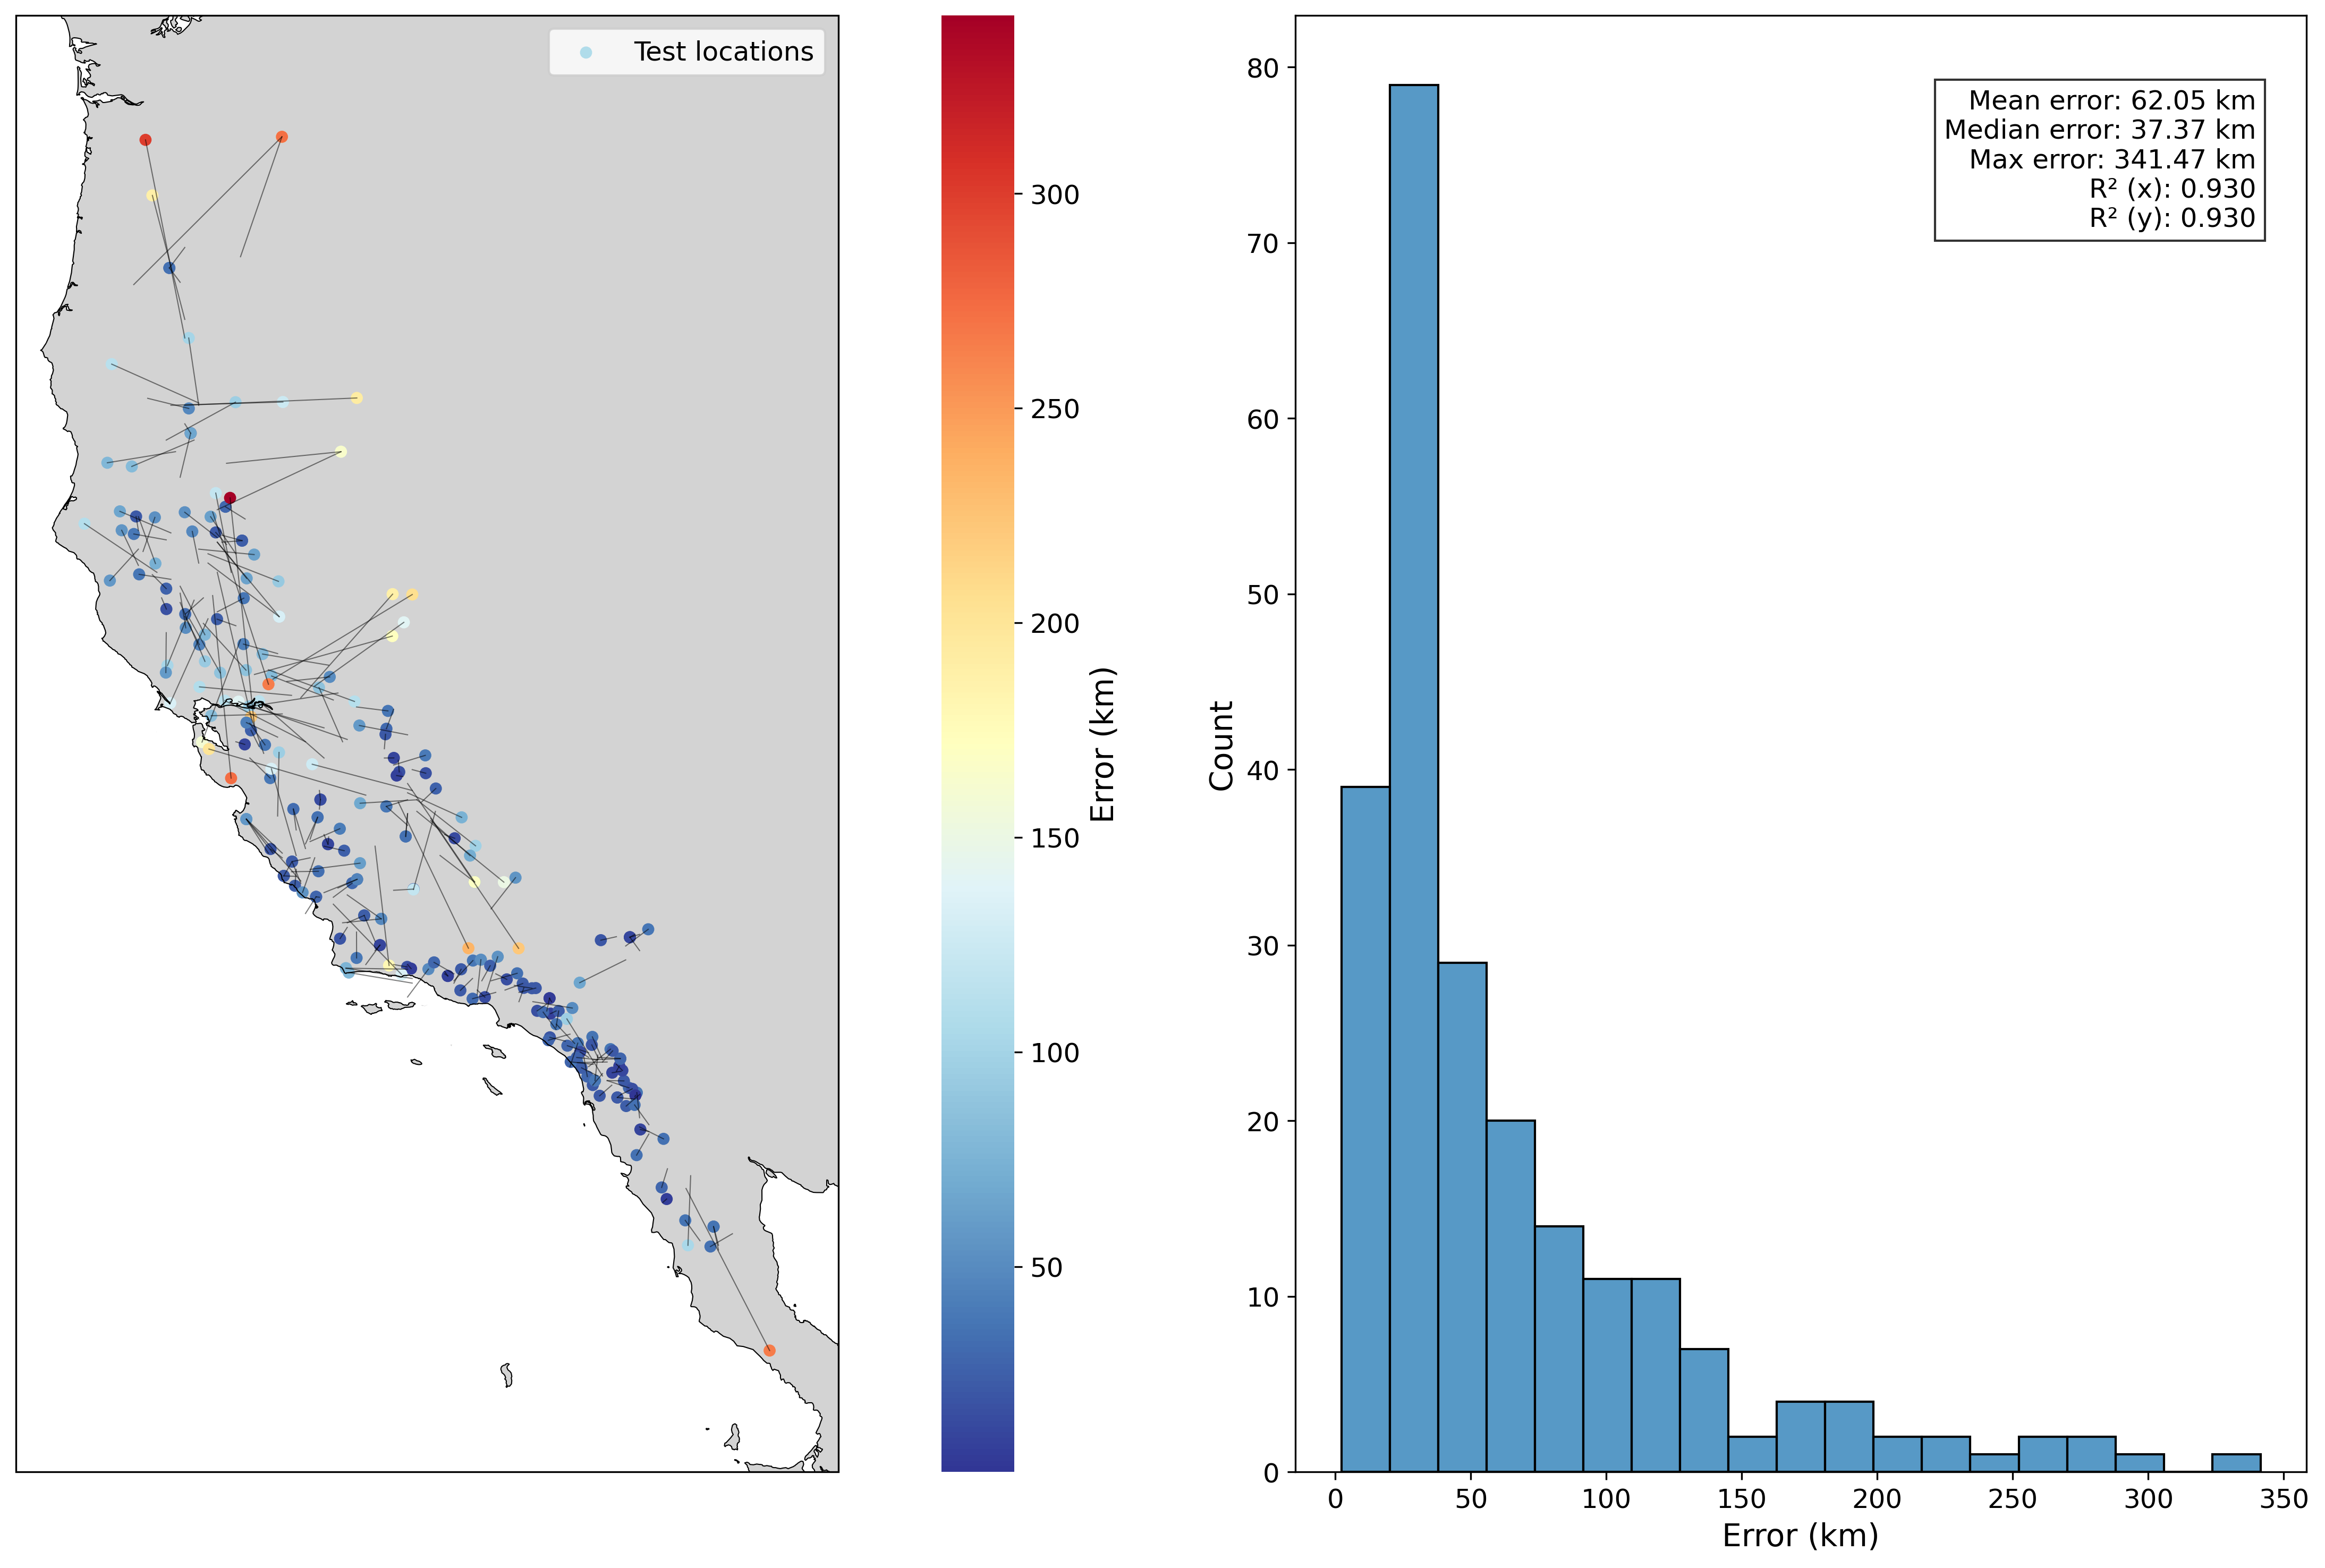

In [12]:
plot_error_summary(
    predictions=par_loo,
    sample_data=coords_path,
    plot_map=True,
    include_training_locs=True,
)

In [4]:
# Import required modules
from locator.parallel import parallel_windows_holdouts

# Run parallel window holdouts analysis
# This will analyze prediction accuracy

holdout_sample_ids = ["Actimarm_HBS118883", "Actmar_APG422"]
window_results = parallel_windows_holdouts(
    locator=locator,
    genotypes=genotypes,
    samples=samples,
    holdout_sample_ids=holdout_sample_ids,
    window_size=1_000_000,  # 10mb windows
    respect_chromosomes=True,  # Respect chromosome boundaries (default)
    gpu_ids=[1, 2],
    gpu_fraction=0.05,
    verbose=True,
    return_df=True,
    save_full_pred_matrix=True,
)

2025-07-05 22:58:58,820	INFO worker.py:1917 -- Started a local Ray instance.


Windows holdout analysis: 231 samples with coordinates, 0 without
Loading SNP positions from VCF...
Loaded 100126 SNP positions
Processing 52 chromosomes: JALMGD010000001.1, JALMGD010000002.1, JALMGD010000003.1, JALMGD010000004.1, JALMGD010000005.1
  ... and 47 more
  Chromosome JALMGD010000001.1: 376 windows
  Chromosome JALMGD010000002.1: 298 windows
  Chromosome JALMGD010000003.1: 218 windows
  Chromosome JALMGD010000004.1: 153 windows
  Chromosome JALMGD010000005.1: 141 windows
  Chromosome JALMGD010000006.1: 139 windows
  Chromosome JALMGD010000007.1: 134 windows
  Chromosome JALMGD010000008.1: 116 windows
  Chromosome JALMGD010000009.1: 110 windows
  Chromosome JALMGD010000010.1: 94 windows
  Chromosome JALMGD010000011.1: 82 windows
  Chromosome JALMGD010000012.1: 50 windows
  Chromosome JALMGD010000013.1: 49 windows
  Chromosome JALMGD010000014.1: 48 windows
  Chromosome JALMGD010000015.1: 37 windows
  Chromosome JALMGD010000016.1: 28 windows
  Chromosome JALMGD010000017.1: 27 w

Windows completed:   0%|          | 0/2351 [00:00<?, ?it/s]

(_ray_windows_worker pid=666562) Worker processing window 9 (9015895-10015895) on GPU 2
(_ray_windows_worker pid=666713) 
(_ray_windows_worker pid=666535) Using GPU 0: /physical_device:GPU:0
(_ray_windows_worker pid=666535) Mixed precision training enabled (compute capability (8, 0))
(_ray_windows_worker pid=666714) Worker processing window 54 (54015895-55015895) on GPU 1 [repeated 59x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_ray_windows_worker pid=666617) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(_ray_windows_worker pid=666617) I0000 00:00:1751781565.254082  666617 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 77641 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0
(_ray_windows_worker pid=666538) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 37x across cluster]
(_ray_windows_worker pid=666538) I0000 00:00:1751781570.351064  666538 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 70980 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0 [repeated 37x across cluster]
(_ray_windows_worker pid=666617) I0000 00:00:1751781573.977862  682635 cuda_dnn.cc:527] Loaded cuDNN version 90300
(_ray_windows_worker pid=666599) WARNING: All log m

...

(_ray_windows_worker pid=2426927) Using GPU 0: /physical_device:GPU:0 [repeated 15x across cluster]
(_ray_windows_worker pid=2425182) Mixed precision training enabled (compute capability (8, 0)) [repeated 14x across cluster]


(_ray_windows_worker pid=2251763) I0000 00:00:1751784261.483275 3382517 cuda_dnn.cc:527] Loaded cuDNN version 90300
Windows completed:  98%|█████████▊| 2309/2351 [45:12<00:28,  1.48it/s, Last: Window 2308 (chrJALMGD010000030.1), GPU 1]

(_ray_windows_worker pid=2448100) Worker processing window 2349 (5658-5659) on GPU 2 [repeated 5x across cluster]


Windows completed:  98%|█████████▊| 2315/2351 [45:14<00:14,  2.54it/s, Last: Window 2307 (chrJALMGD010000030.1), GPU 2](_ray_windows_worker pid=2421975) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 15x across cluster]
(_ray_windows_worker pid=2421975) I0000 00:00:1751784263.527307 2421975 gpu_device.cc:2018] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 68568 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0 [repeated 15x across cluster]
(_ray_windows_worker pid=2251211) I0000 00:00:1751784265.425739 3277524 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
(_ray_windows_worker pid=2252470) I0000 00:00:1751784262.487133 3395811 cuda_dnn.cc:527] Loaded cuDNN version 90300 [repeated 3x across cluster]
(_ray_windows_worker pid=2251390) I0000 00:00:1751784268.507927 3300359 device_compiler.h:196] Co


Completed 2351 windows in 2755.4s (1.2s per window)

GPU utilization:
  GPU 1: 1176 windows (50.0%)
  GPU 2: 1175 windows (50.0%)


/home/adkern/miniforge3/envs/relocator/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/adkern/miniforge3/envs/relocator/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)


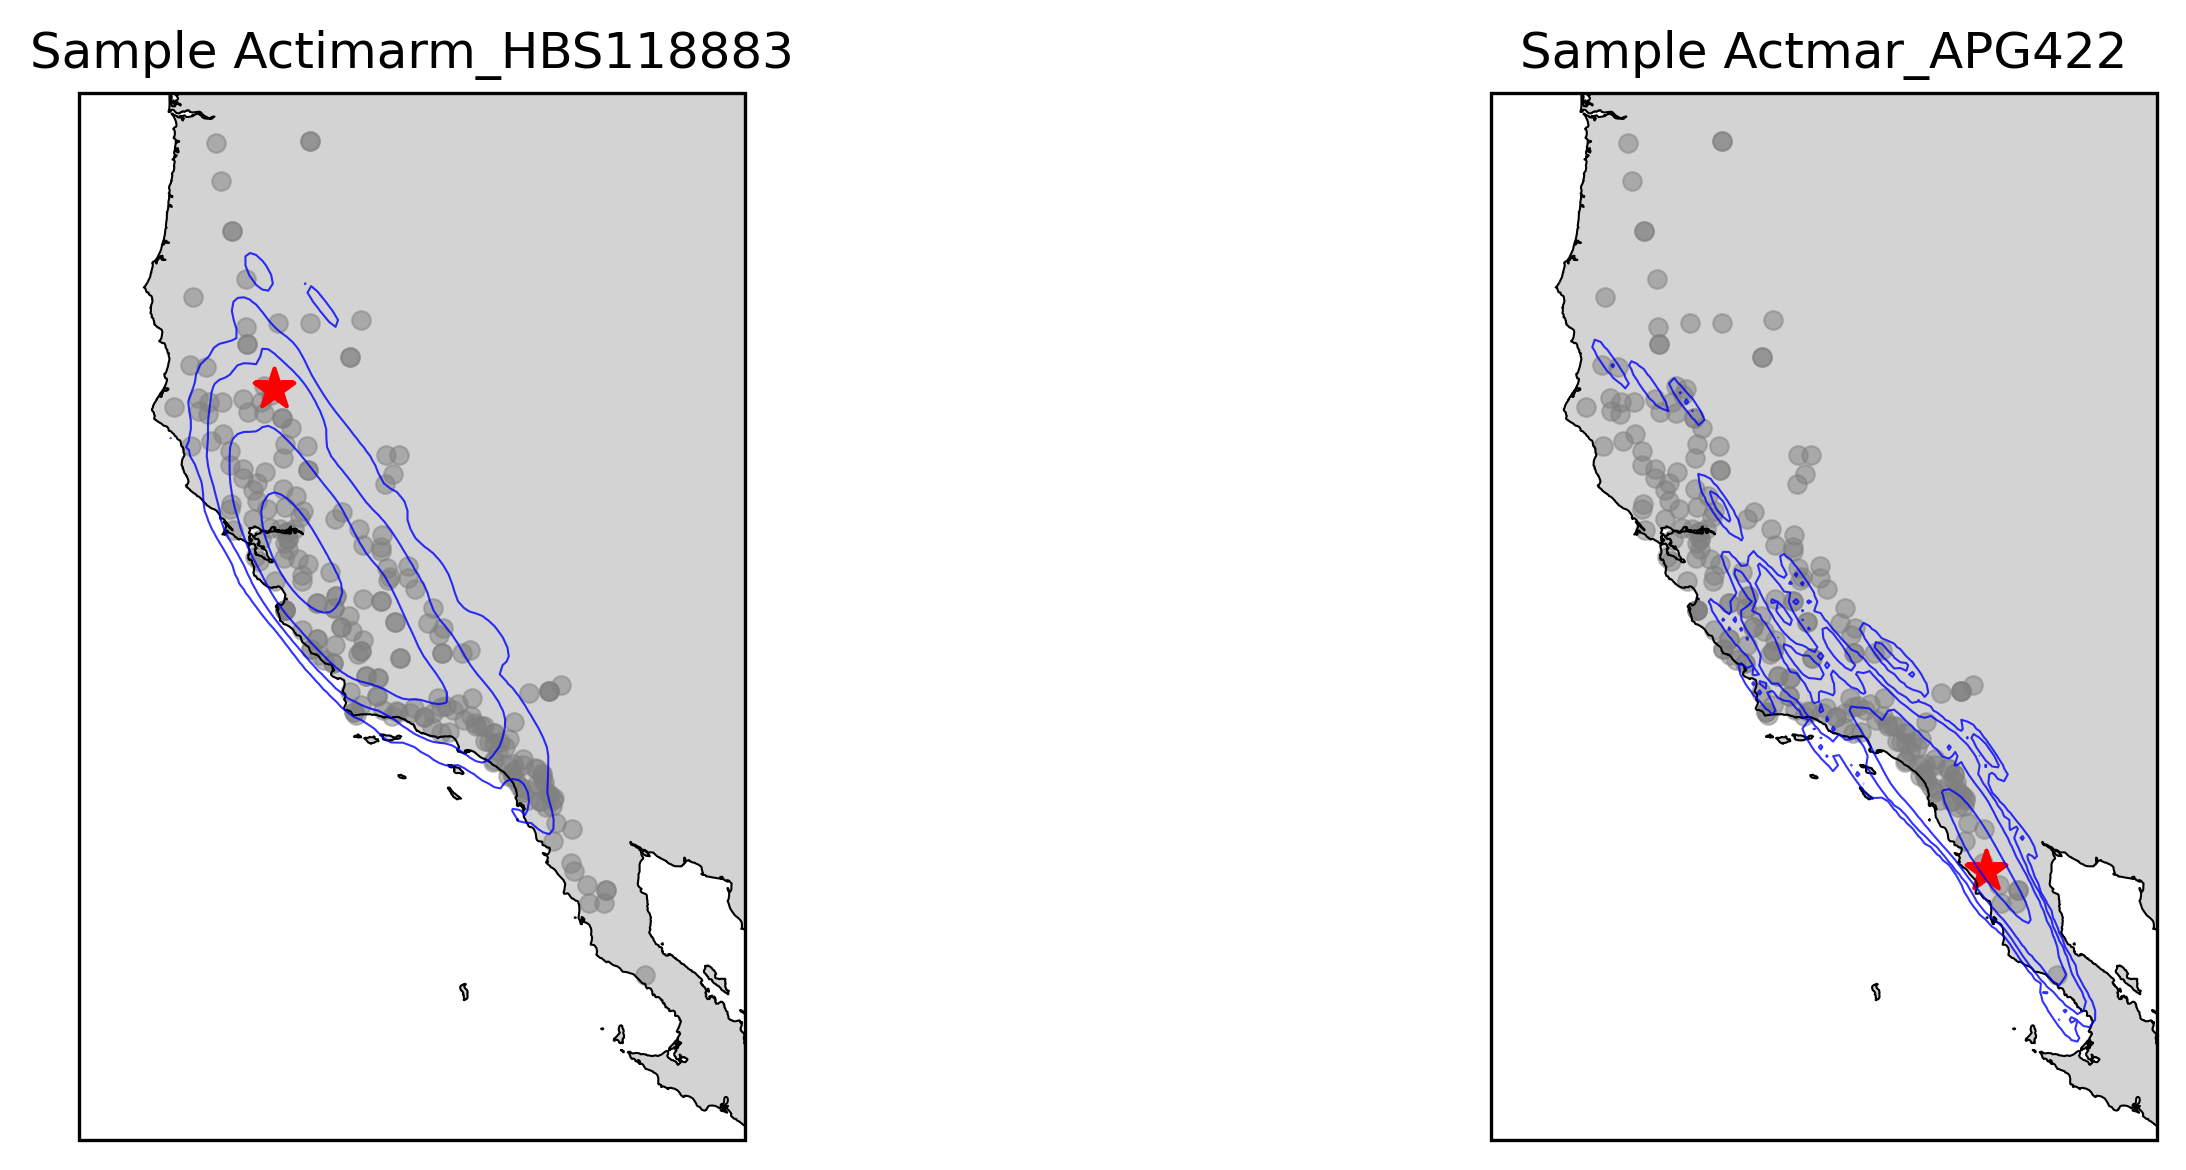

In [4]:
from locator.plotting import plot_predictions

plot_predictions(
    predictions=window_results,
    locator=locator,
    out_prefix=os.path.join(output_dir, "window_holdouts"),
    plot_map=True,
)

In [5]:
window_results

,x_chrJALMGD010000003.1_pos15085,y_chrJALMGD010000003.1_pos15085,sampleID,x_chrJALMGD010000002.1_pos130014099,y_chrJALMGD010000002.1_pos130014099,x_chrJALMGD010000001.1_pos30015895,y_chrJALMGD010000001.1_pos30015895,x_chrJALMGD010000001.1_pos60015895,y_chrJALMGD010000001.1_pos60015895,x_chrJALMGD010000001.1_pos40015895,...,x_chrJALMGD010000035.1_pos19785,y_chrJALMGD010000035.1_pos19785,x_chrJALMGD010000020.1_pos86053,y_chrJALMGD010000020.1_pos86053,x_chrJALMGD010000026.1_pos24875,y_chrJALMGD010000026.1_pos24875,x_chrJALMGD010000028.1_pos125109,y_chrJALMGD010000028.1_pos125109,x_chrJALMGD010000029.1_pos61519,y_chrJALMGD010000029.1_pos61519
0,-122.5000,38.812500,115407,-122.7500,41.343750,-123.3750,41.250000,-122.5625,40.09375,-121.6875,...,-121.7500,40.937500,-122.5625,39.34375,-122.4375,40.875000,-123.6250,40.21875,-122.6875,40.09375
1,-120.8125,35.500000,Actmar_HBS114039,-119.7500,34.406250,-120.0625,35.062500,-120.0625,35.25000,-121.0000,...,-120.6250,36.187500,-120.4375,35.87500,-120.6250,35.875000,-121.0625,36.15625,-120.3125,35.46875
2,-119.3750,34.656250,116028,-120.3125,34.687500,-118.6250,34.250000,-118.8750,34.46875,-118.8125,...,-118.5000,34.375000,-119.8750,34.71875,-118.9375,34.593750,-118.4375,34.31250,-118.8125,34.25000
3,-118.6250,35.625000,116079,-119.1875,36.375000,-119.8125,37.437500,-119.4375,36.65625,-119.3750,...,-119.0625,36.375000,-120.0625,36.15625,-120.7500,37.718750,-120.2500,36.34375,-119.6875,36.50000
4,-122.5000,38.843750,Actimarm_HBS120393,-122.5625,39.625000,-120.5625,40.406250,-122.3750,39.59375,-121.6250,...,-122.4375,40.093750,-122.1875,38.59375,-122.1875,38.406250,-121.8125,38.75000,-121.3750,38.09375
5,-120.5625,36.562500,Actimarm_HBS117919,-121.3750,37.593750,-119.4375,36.562500,-120.4375,37.56250,-120.1875,...,-118.8125,36.312500,-119.3750,37.28125,-119.1875,35.906250,-121.5625,38.56250,-119.8750,37.09375
6,-121.9375,41.500000,Actimarm_Lake2019-01_100,-122.5000,43.093750,-123.4375,41.937500,-122.6875,40.62500,-121.9375,...,-120.3125,40.468750,-122.5000,41.37500,-122.0625,40.968750,-122.6875,41.00000,-122.0000,40.40625
7,-121.8125,39.250000,Actimarm_HBS115640,-121.8750,40.500000,-121.3125,39.343750,-121.8750,38.87500,-121.0000,...,-122.9375,39.562500,-121.8125,40.40625,-120.9375,38.406250,-122.1875,39.50000,-120.1250,36.34375
8,-120.7500,35.500000,Actpal_AJL23-036-S032,-118.5625,34.187500,-120.0000,34.843750,-118.8125,34.56250,-120.1875,...,-121.5000,36.312500,-120.3125,34.68750,-119.7500,34.875000,-118.6250,34.59375,-119.3125,35.18750
9,-122.3750,39.718750,115089,-123.1250,42.156250,-123.0000,40.906250,-123.0625,40.90625,-121.8750,...,-122.4375,41.843750,-122.1875,39.90625,-121.7500,39.875000,-121.4375,38.56250,-123.1250,41.46875
